# RE608 Legged Robot - Week 7: Gait Planning
## Program Studi Teknologi Rekayasa Robotika - Politeknik Negeri Batam

### Student Information

**Name:** Yosua Dirgana Pratama  
**Student ID:** 4222301009

---

Notebook ini mendemonstrasikan bagaimana merencanakan jadwal fase gerak (*gait scheduler*) dan memvisualisasikan diagram *gait* untuk robot berkaki. Fokus utama tugas ini adalah merancang **Tripod Gait untuk Hexapod Robot**, menentukan **phase offset**, **duty factor**, serta melakukan **verifikasi stabilitas menggunakan support polygon**.

Selain itu dilakukan analisis perbandingan stabilitas antara **Tripod Gait pada Hexapod** dan **Trot Gait pada Quadruped**.

In [15]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.animation import FuncAnimation
from scipy.spatial import ConvexHull
from IPython.display import HTML
import matplotlib

matplotlib.rcParams['animation.html'] = 'jshtml'
print("✅ Environment siap!")

✅ Environment siap!


### 1. Definisi Parameter Gait & Quadruped Scheduler
Sebuah siklus *gait* ditentukan oleh beberapa parameter utama:
- **Stride Period (T):** Waktu yang dibutuhkan untuk menyelesaikan satu siklus penuh.
- **Duty Factor ($\beta$):** Rasio waktu kaki berada di tanah (*stance phase*) dibandingkan dengan total periode siklus.
- **Phase Offset ($\phi$):** Perbedaan waktu mulai siklus antar kaki.

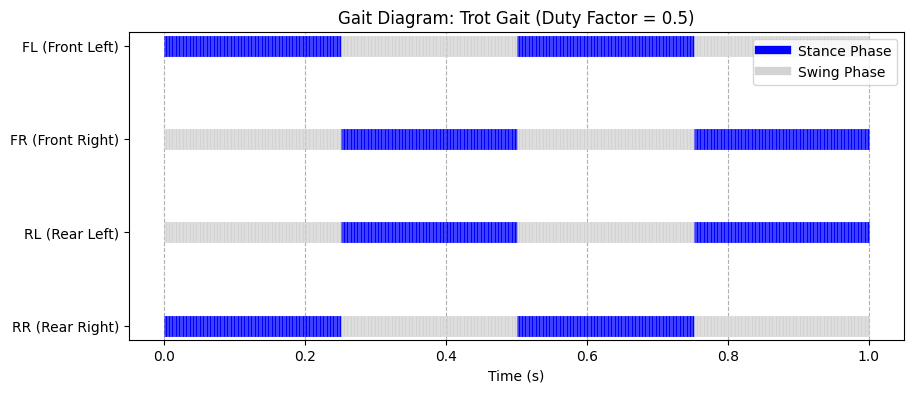

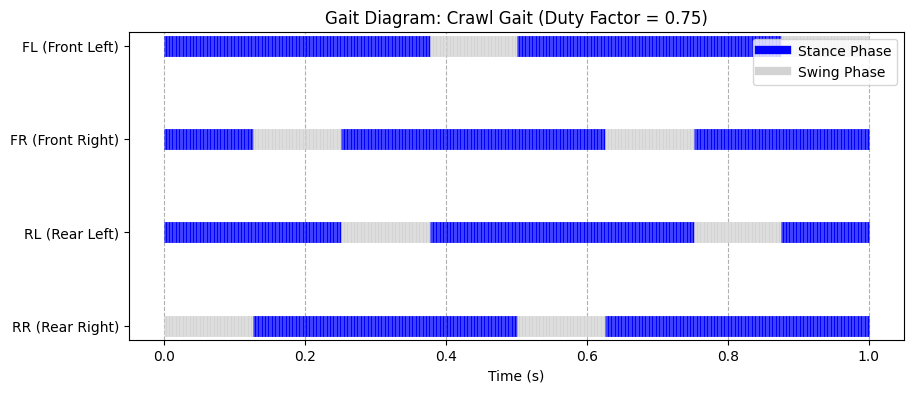

In [16]:
class QuadrupedGaitScheduler:
    def __init__(self, T=1.0):
        self.T = T
        self.legs = ['FL (Front Left)', 'FR (Front Right)', 'RL (Rear Left)', 'RR (Rear Right)']

    def get_phase(self, t, offset):
        # Menghitung fase dari 0.0 hingga 1.0
        return ((t / self.T) + offset) % 1.0

    def plot_gait_diagram(self, duty_factor, offsets, title):
        time_steps = np.linspace(0, 2 * self.T, 500) # Plot untuk 2 siklus

        fig, ax = plt.subplots(figsize=(10, 4))
        for i, (leg, offset) in enumerate(zip(self.legs, offsets)):
            phases = self.get_phase(time_steps, offset)
            # Stance (kaki di tanah) = 1, Swing (kaki di udara) = 0
            stance = np.where(phases < duty_factor, 1, 0)

            # Plotting diagram Gantt
            for t_idx in range(len(time_steps)-1):
                if stance[t_idx] == 1:
                    ax.plot([time_steps[t_idx], time_steps[t_idx+1]], [3-i, 3-i], color='blue', lw=15, solid_capstyle='butt')
                else:
                    ax.plot([time_steps[t_idx], time_steps[t_idx+1]], [3-i, 3-i], color='lightgray', lw=15, solid_capstyle='butt')

        ax.set_yticks([0, 1, 2, 3])
        ax.set_yticklabels(self.legs[::-1])
        ax.set_xlabel('Time (s)')
        ax.set_title(f'Gait Diagram: {title} (Duty Factor = {duty_factor})')
        ax.grid(axis='x', linestyle='--')

        # Legend custom
        custom_lines = [plt.Line2D([0], [0], color='blue', lw=6), plt.Line2D([0], [0], color='lightgray', lw=6)]
        ax.legend(custom_lines, ['Stance Phase', 'Swing Phase'], loc='upper right')

        plt.show()

# Inisialisasi scheduler
scheduler = QuadrupedGaitScheduler(T=0.5)

# 1. Trot Gait: Pasangan diagonal bergerak bersamaan
trot_offsets = [0.0, 0.5, 0.5, 0.0]  # [FL, FR, RL, RR]
scheduler.plot_gait_diagram(duty_factor=0.5, offsets=trot_offsets, title='Trot Gait')

# 2. Crawl Gait: Gerak bergantian satu per satu, sangat stabil statis
crawl_offsets = [0.0, 0.5, 0.25, 0.75] # [FL, FR, RL, RR]
scheduler.plot_gait_diagram(duty_factor=0.75, offsets=crawl_offsets, title='Crawl Gait')



## Hexapod Tripod Foot Trajectory

Visualisasi berikut menunjukkan lintasan kaki (foot trajectory) untuk robot hexapod menggunakan tripod gait.

Tripod Group A:
- FL (Front Left)
- MR (Middle Right)
- BL (Back Left)

Tripod Group B:
- FR (Front Right)
- ML (Middle Left)
- BR (Back Right)

Ketiga kaki dalam grup yang sama bergerak dengan fase yang sama, sedangkan grup lainnya memiliki phase offset sebesar 0.5.

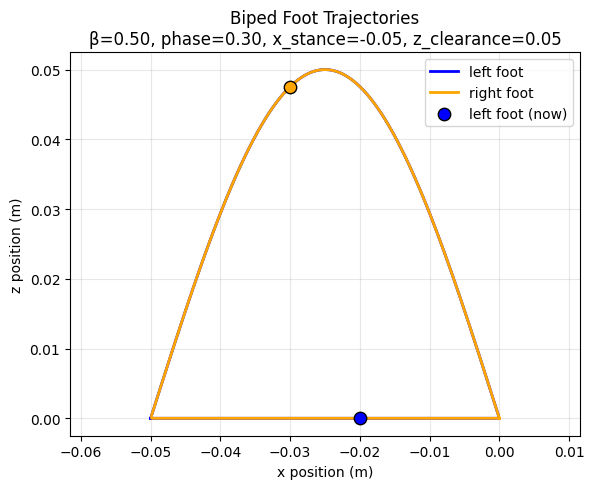

In [17]:
import numpy as np
import matplotlib.pyplot as plt

def foot_position_cmd(phase, beta, x_stance=-0.05, x_lift=0.0,
                      z_ground=0.0, z_clearance=0.05):
    """Return desired (x, z) foot position for leg phase in [0,1)."""
    if phase < beta:  # stance
        t = phase / beta
        x = x_stance + (x_lift - x_stance) * t
        z = z_ground
    else:  # swing
        t = (phase - beta) / (1.0 - beta)
        x = x_lift + (x_stance - x_lift) * t
        z = z_clearance * np.sin(np.pi * t)
    return x, z

# ----- Editable parameters -----
beta = 0.5          # duty factor (stance fraction)
phase = 0.3         # current phase (0..1) to show instantaneous foot positions
x_stance = -0.05    # x position during stance (m)
x_lift = 0.0        # x position at lift-off / touch-down (m)
z_ground = 0.0      # ground height (m)
z_clearance = 0.05  # max foot height during swing (m)
# --------------------------------

T = 1.0  # period of one gait cycle (s)
t = np.linspace(0, T, 400)
phases = t / T  # 0 to 1

# Offsets for left and right foot (opposite phase)
offsets = {'left': 0.0, 'right': 0.5}

plt.figure(figsize=(6,5))
for leg, offset in offsets.items():
    xs, zs = [], []
    for ph in phases:
        x, z = foot_position_cmd((ph + offset) % 1.0,
                                 beta, x_stance, x_lift,
                                 z_ground, z_clearance)
        xs.append(x); zs.append(z)
    color = 'blue' if leg == 'left' else 'orange'
    plt.plot(xs, zs, label=f'{leg} foot', color=color, linewidth=2)

# Instantaneous positions at current phase
cur_xs, cur_zs = [], []
for leg, offset in offsets.items():
    ph_cur = (phase + offset) % 1.0
    x_cur, z_cur = foot_position_cmd(ph_cur, beta,
                                     x_stance, x_lift,
                                     z_ground, z_clearance)
    cur_xs.append(x_cur); cur_zs.append(z_cur)
    color = 'blue' if leg == 'left' else 'orange'
    plt.scatter([x_cur], [z_cur], color=color, s=80, zorder=5,
                edgecolors='k', label=f'{leg} foot (now)' if leg == 'left' else None)

plt.xlabel('x position (m)')
plt.ylabel('z position (m)')
plt.title('Biped Foot Trajectories\n'
          f'β={beta:.2f}, phase={phase:.2f}, x_stance={x_stance:.2f}, '
          f'z_clearance={z_clearance:.2f}')
plt.grid(True, alpha=0.3)
plt.legend(loc='upper right')
plt.axis('equal')
plt.tight_layout()
plt.show()

### 2. Assignment: Hexapod Tripod Gait Design

Sesuai materi perkuliahan minggu ini, hexapod dapat menggunakan *tripod gait* di mana 3 kaki membentuk fondasi segitiga yang stabil, secara bergantian (alternating triangles).

**Tugas Praktikum:**
1. Modifikasi kelas/fungsi di atas agar mampu menangani 6 kaki (L1, L2, L3, R1, R2, R3).
2. Buat matriks `offsets` dan tentukan *duty factor* yang tepat untuk *Tripod Gait*.
3. Plot diagram *gait*-nya dan verifikasi kelayakan stabilitasnya.
4. Tuliskan analisis Anda mengenai perbedaan stabilitas antara *Trot Quadruped* dengan *Tripod Hexapod* di sel *markdown* bawah.

---
**Catatan Implementasi Teknis Lanjutan:**
Nantinya saat Anda mengintegrasikan luaran *gait scheduler* ini ke simulasi skrip *forward/inverse kinematics* Anda, pastikan *coxa* dipaksa beroperasi konstan pada bidang XY. Selain itu, Anda harus menghapus keberadaan titik koordinat *base* dari matriks simulasi kakinya. Hal ini akan mencegah perhitungan matriks singular dan mempercepat konvergensi algoritma IK saat transisi fase *stance* ke *swing*.

In [18]:
# TODO: Implementasikan Hexapod Tripod Gait Anda di bawah ini
# hexapod_legs = ['L1', 'L2', 'L3', 'R1', 'R2', 'R3']

# Tulis kode Anda di sini...


# RE608 Legged Robot - Week 7
## Hexapod Tripod Gait Design

### Student Information

**Name:** Yosua Dirgana Pratama  
**Student ID:** 4222301009  
**Study Program:** Teknologi Rekayasa Robotika  
**Institution:** Politeknik Negeri Batam

---

### Objectives

1. Memahami konsep Tripod Gait pada Hexapod.
2. Mengimplementasikan gait scheduler untuk 6 kaki.
3. Menentukan phase offset dan duty factor.
4. Memvisualisasikan gait diagram.
5. Menganalisis stabilitas tripod gait dibandingkan trot gait quadruped.

---

### Assignment Tasks

1. Modifikasi gait scheduler agar mendukung 6 kaki (L1, L2, L3, R1, R2, R3).
2. Menentukan phase offset dan duty factor untuk Tripod Gait.
3. Membuat visualisasi gait diagram selama 2 stride cycles.
4. Memverifikasi stabilitas tripod gait menggunakan support polygon.
5. Menganalisis perbedaan stabilitas antara Trot Quadruped dan Tripod Hexapod.

In [19]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from matplotlib.animation import FuncAnimation
from IPython.display import HTML

print("✅ Environment siap!")

✅ Environment siap!


## 1. Hexapod Tripod Gait

Tripod gait merupakan salah satu gait yang paling umum digunakan pada robot hexapod.

Enam kaki dibagi menjadi dua kelompok tripod yang bergerak secara bergantian.

### Tripod Group A
- L1
- L3
- R2

### Tripod Group B
- L2
- R1
- R3

Ketika Tripod Group A berada pada fase stance, Tripod Group B berada pada fase swing, dan sebaliknya.

Duty factor yang digunakan pada implementasi ini adalah:

β = 0.5

In [20]:
class HexapodGaitScheduler:

    def __init__(self, T=1.0):

        self.T = T

        self.legs = [
            'L1',
            'L2',
            'L3',
            'R1',
            'R2',
            'R3'
        ]

    def get_phase(self, t, offset):

        return (
            (t / self.T)
            + offset
        ) % 1.0

## 1.1 Hexapod Tripod Gait Diagram

Diagram berikut menunjukkan pola stance dan swing untuk setiap kaki selama dua siklus gait penuh.


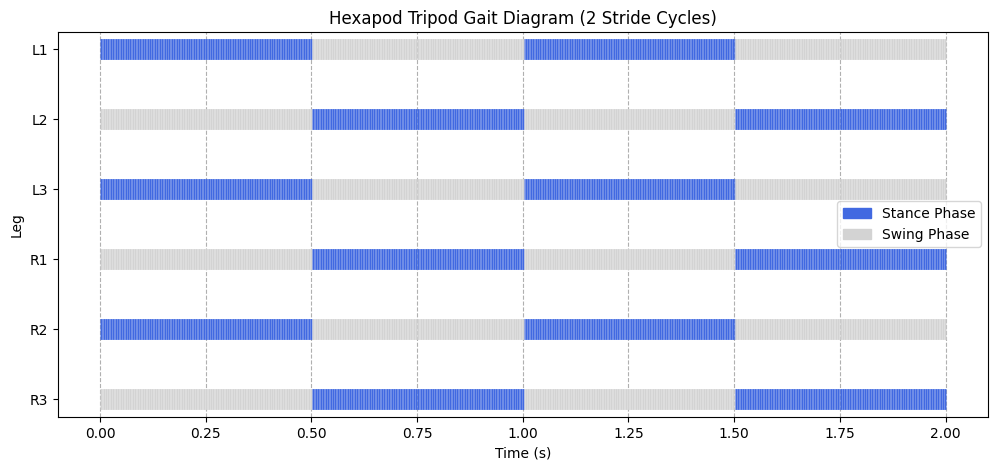

In [21]:
scheduler = HexapodGaitScheduler(T=1.0)

offsets = {

    # Tripod A
    'L1':0.0,
    'L3':0.0,
    'R2':0.0,

    # Tripod B
    'L2':0.5,
    'R1':0.5,
    'R3':0.5
}

beta = 0.5

time_steps = np.linspace(
    0,
    2,
    500
)

fig, ax = plt.subplots(figsize=(12,5))

for i, leg in enumerate(scheduler.legs):

    phase = scheduler.get_phase(
        time_steps,
        offsets[leg]
    )

    stance = phase < beta

    for j in range(len(time_steps)-1):

        color = (
            'royalblue'
            if stance[j]
            else 'lightgray'
        )

        ax.plot(
            [
                time_steps[j],
                time_steps[j+1]
            ],
            [5-i,5-i],
            color=color,
            lw=15,
            solid_capstyle='butt'
        )

ax.set_yticks(range(6))

ax.set_yticklabels(
    scheduler.legs[::-1]
)

ax.set_xlabel("Time (s)")
ax.set_ylabel("Leg")

ax.set_title(
    "Hexapod Tripod Gait Diagram (2 Stride Cycles)"
)

ax.grid(
    axis='x',
    linestyle='--'
)

ax.legend(
    handles=[
        mpatches.Patch(
            color='royalblue',
            label='Stance Phase'
        ),
        mpatches.Patch(
            color='lightgray',
            label='Swing Phase'
        )
    ]
)

plt.show()

## 1.2 Gait Parameters

Parameter yang digunakan pada implementasi tripod gait ditunjukkan berikut ini.

In [22]:
print("Hexapod Tripod Gait Parameters")
print("="*40)

print(f"Stride Period (T) : {scheduler.T} s")
print(f"Duty Factor (β)   : {beta}")

print("\nTripod Group A")
print("L1, L3, R2")

print("\nTripod Group B")
print("L2, R1, R3")

Hexapod Tripod Gait Parameters
Stride Period (T) : 1.0 s
Duty Factor (β)   : 0.5

Tripod Group A
L1, L3, R2

Tripod Group B
L2, R1, R3


## 2. Stability Verification

Untuk memverifikasi stabilitas tripod gait, digunakan support polygon yang dibentuk oleh kaki-kaki yang sedang berada pada fase stance.

Pada tripod gait, selalu terdapat tiga kaki yang menyentuh tanah sehingga terbentuk support polygon berbentuk segitiga.

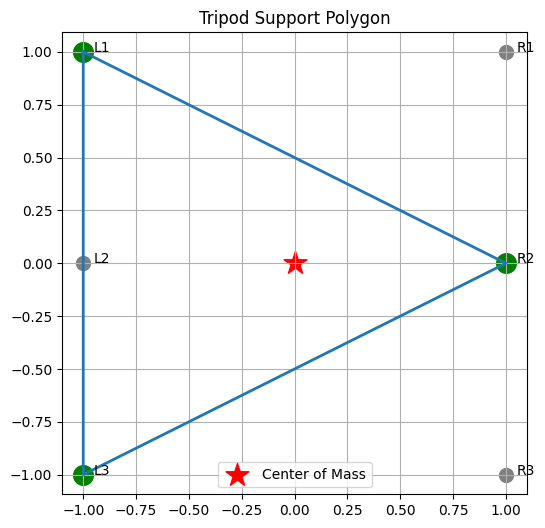

In [23]:
feet = {
    'L1':(-1,1),
    'L2':(-1,0),
    'L3':(-1,-1),
    'R1':(1,1),
    'R2':(1,0),
    'R3':(1,-1)
}

tripodA = ['L1','L3','R2']

plt.figure(figsize=(6,6))

for leg,pos in feet.items():

    if leg in tripodA:

        plt.scatter(
            pos[0],
            pos[1],
            s=200,
            color='green'
        )

        plt.text(
            pos[0]+0.05,
            pos[1],
            leg
        )

    else:

        plt.scatter(
            pos[0],
            pos[1],
            s=100,
            color='gray'
        )

        plt.text(
            pos[0]+0.05,
            pos[1],
            leg
        )

triangle = np.array([
    feet['L1'],
    feet['L3'],
    feet['R2'],
    feet['L1']
])

plt.plot(
    triangle[:,0],
    triangle[:,1],
    linewidth=2
)

plt.scatter(
    0,
    0,
    marker='*',
    s=300,
    color='red',
    label='Center of Mass'
)

plt.title(
    "Tripod Support Polygon"
)

plt.axis('equal')
plt.grid(True)
plt.legend()

plt.show()

## 2.1 Stability Verification Result

In [24]:
print("Support Polygon Verification")
print("="*40)

print("Active Stance Legs:")
print(tripodA)

print("\nCenter of Mass:")
print("(0, 0)")

print("\nVerification Result:")
print("✅ Stable")

print("\nReason:")
print("The Center of Mass remains inside the triangular support polygon.")

Support Polygon Verification
Active Stance Legs:
['L1', 'L3', 'R2']

Center of Mass:
(0, 0)

Verification Result:
✅ Stable

Reason:
The Center of Mass remains inside the triangular support polygon.


## 3. Stability Analysis

Tripod gait membagi enam kaki menjadi dua kelompok tripod yang bergerak secara bergantian.

Pada setiap saat terdapat tiga kaki yang menyentuh tanah dan membentuk support polygon berbentuk segitiga.

Dibandingkan dengan trot gait pada quadruped, tripod gait memiliki stabilitas yang lebih baik karena pusat massa robot tetap berada di dalam area tumpuan selama siklus berjalan.

In [25]:
print("STABILITY ANALYSIS")
print("="*50)

print("Tripod Gait:")
print("- 3 legs remain in contact with the ground.")
print("- Forms a triangular support polygon.")
print("- Center of Mass stays inside the support area.")
print("- Higher static stability.")

print("\nQuadruped Trot Gait:")
print("- Only 2 diagonal legs remain in contact.")
print("- Smaller support area.")
print("- More sensitive to CoM movement.")
print("- Lower static stability.")

STABILITY ANALYSIS
Tripod Gait:
- 3 legs remain in contact with the ground.
- Forms a triangular support polygon.
- Center of Mass stays inside the support area.
- Higher static stability.

Quadruped Trot Gait:
- Only 2 diagonal legs remain in contact.
- Smaller support area.
- More sensitive to CoM movement.
- Lower static stability.


## 4. Comparison Between Quadruped Trot and Hexapod Tripod

| Aspect | Quadruped Trot | Hexapod Tripod |
|----------|----------|----------|
| Number of Legs | 4 | 6 |
| Legs in Stance | 2 | 3 |
| Support Polygon | Small | Larger |
| Static Stability | Medium | High |
| Walking Speed | Higher | Moderate |
| Terrain Adaptability | Lower | Higher |

In [26]:
comparison = [
    ["Number of Legs", "4", "6"],
    ["Legs in Stance", "2", "3"],
    ["Support Polygon", "Small", "Larger"],
    ["Static Stability", "Medium", "High"],
    ["Walking Speed", "Higher", "Moderate"],
    ["Terrain Adaptability", "Lower", "Higher"]
]

print(f"{'Aspect':<25}{'Quadruped Trot':<20}{'Hexapod Tripod':<20}")
print("-"*65)

for row in comparison:
    print(f"{row[0]:<25}{row[1]:<20}{row[2]:<20}")

Aspect                   Quadruped Trot      Hexapod Tripod      
-----------------------------------------------------------------
Number of Legs           4                   6                   
Legs in Stance           2                   3                   
Support Polygon          Small               Larger              
Static Stability         Medium              High                
Walking Speed            Higher              Moderate            
Terrain Adaptability     Lower               Higher              


## 5. Hexapod Gait Scheduler Animation

Pada bagian ini dilakukan animasi gait scheduler untuk memperlihatkan perubahan fase stance dan swing dari keenam kaki secara real-time.

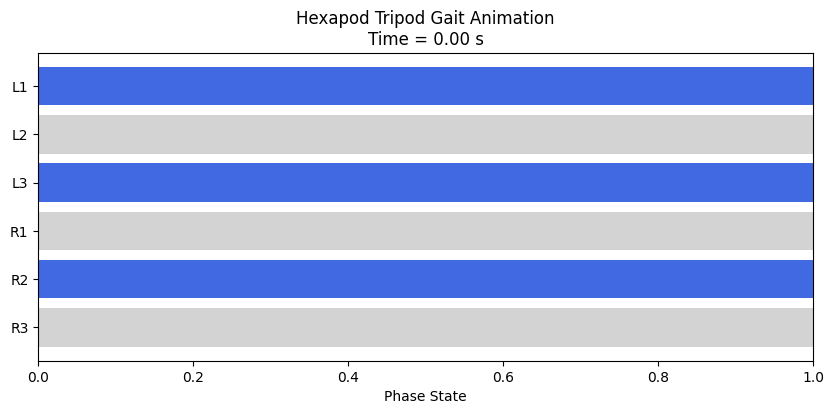

In [27]:
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

fig, ax = plt.subplots(figsize=(10,4))

legs = scheduler.legs

def update(frame):

    ax.clear()

    t = frame / 50.0

    for i, leg in enumerate(legs):

        phase = scheduler.get_phase(
            t,
            offsets[leg]
        )

        stance = phase < beta

        color = "royalblue" if stance else "lightgray"

        ax.barh(
            5-i,
            1,
            color=color
        )

    ax.set_yticks(range(6))
    ax.set_yticklabels(legs[::-1])

    ax.set_xlim(0,1)

    ax.set_title(
        f"Hexapod Tripod Gait Animation\nTime = {t:.2f} s"
    )

    ax.set_xlabel("Phase State")

ani = FuncAnimation(
    fig,
    update,
    frames=100,
    interval=100
)

HTML(ani.to_jshtml())

## 6. Trot vs Crawl Stability Analysis

Pada bagian ini dilakukan simulasi gait quadruped untuk membandingkan stabilitas Trot (β=0.5) dan Crawl (β=0.8).

In [28]:
quad_feet = {
    'FL':(-1,1),
    'FR':(1,1),
    'RL':(-1,-1),
    'RR':(1,-1)
}

com = np.array([0,0])

def plot_support_polygon(
    stance_legs,
    title
):

    plt.figure(figsize=(5,5))

    points = []

    for leg,pos in quad_feet.items():

        if leg in stance_legs:

            plt.scatter(
                pos[0],
                pos[1],
                s=250,
                color='green'
            )

            points.append(pos)

        else:

            plt.scatter(
                pos[0],
                pos[1],
                s=120,
                color='gray'
            )

        plt.text(
            pos[0]+0.05,
            pos[1],
            leg
        )

    if len(points) >= 3:

        poly = np.array(points + [points[0]])

        plt.plot(
            poly[:,0],
            poly[:,1],
            linewidth=2
        )

    plt.scatter(
        0,
        0,
        marker='*',
        s=300,
        color='red',
        label='CoM'
    )

    plt.title(title)

    plt.axis('equal')
    plt.grid(True)
    plt.legend()

    plt.show()

### 6.1 Trot Gait (β = 0.5)

Pada trot gait hanya dua kaki diagonal yang menyentuh tanah secara bersamaan.

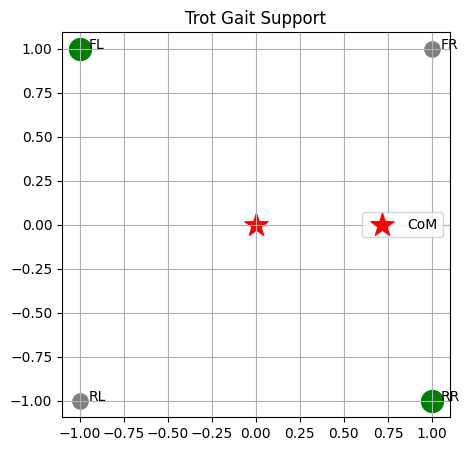

TROT RESULT
❌ Potentially Unstable
Only two diagonal support legs.


In [29]:
trot_stance = [
    'FL',
    'RR'
]

plot_support_polygon(
    trot_stance,
    "Trot Gait Support"
)

print("TROT RESULT")
print("❌ Potentially Unstable")
print("Only two diagonal support legs.")

### 6.2 Crawl Gait (β = 0.8)

Pada crawl gait tiga kaki tetap berada pada fase stance sehingga robot memiliki support polygon yang lebih besar.

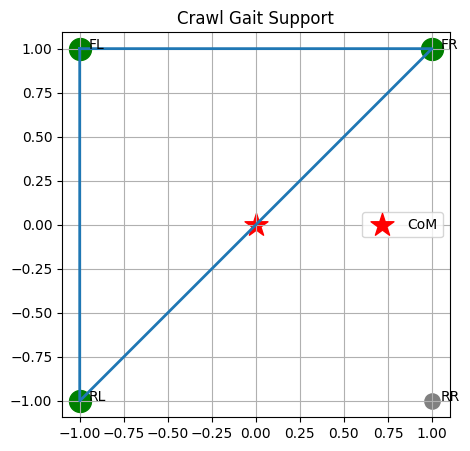

CRAWL RESULT
✅ Stable
Three support legs form a stable support polygon.


In [30]:
crawl_stance = [
    'FL',
    'FR',
    'RL'
]

plot_support_polygon(
    crawl_stance,
    "Crawl Gait Support"
)

print("CRAWL RESULT")
print("✅ Stable")
print("Three support legs form a stable support polygon.")

## 7. Trot vs Crawl Stability Comparison

Hasil simulasi menunjukkan bahwa:

- Trot gait memiliki dua kaki tumpuan sehingga support polygon sangat kecil.
- Crawl gait mempertahankan tiga kaki tumpuan sehingga support polygon lebih besar.
- Crawl gait lebih stabil secara statis dibandingkan trot gait.

## Conclusion

1. Hexapod tripod gait berhasil diimplementasikan menggunakan 6 kaki.
2. Duty factor yang digunakan adalah β = 0.5.
3. Phase offset dibagi menjadi dua grup tripod yang bergerak bergantian.
4. Gait diagram menunjukkan pola stance dan swing yang sesuai dengan tripod gait.
5. Support polygon berbentuk segitiga menjaga stabilitas robot selama berjalan.
6. Tripod gait lebih stabil dibandingkan trot gait pada quadruped.